# Speech Emotion Recognition & Speaker Identification with SincNet
**ECS7013P Deep Learning for Audio & Music**

This notebook trains three SincNet-based models on the RAVDESS dataset:
1. **EmotionSincNet** — classifies 4 emotions (speaker-independent test)
2. **SpeakerSincNet** — identifies 24 speakers (closed-set identification)
3. **MultiTaskSincNet** — shared encoder with both task heads


In [1]:
import os, sys, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

sys.path.insert(0, '.')
from data_utils import (collect_file_paths, split_by_speaker, split_random_per_speaker,
                         prepare_dataloaders, EMOTION_LABELS, print_dataset_stats)
from sincnet import EmotionSincNet, SpeakerSincNet, MultiTaskSincNet

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

SEED = 42
MAX_EPOCHS = 100
PATIENCE = 10
N_BATCHES = 800  # number of mini-batches per epoch (paper uses 800)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

[HAMI-core Msg(164:140586102521152:libvgpu.c:839)]: Initializing.....


Device: cuda


[HAMI-core Msg(164:140586102521152:libvgpu.c:855)]: Initialized


## 1. Data Loading


In [2]:
DATA_DIR = 'audio_speech_actors_01-24'
samples = collect_file_paths(DATA_DIR)
print_dataset_stats(samples)

# Emotion: speaker-independent split (test speakers never seen in training)
emo_train, emo_val, emo_test = split_by_speaker(samples, val_speakers=[3, 4], test_speakers=[23, 24])

# Speaker: random split (all 24 speakers in train — required for closed-set identification)
spk_train, spk_val, spk_test = split_random_per_speaker(samples)

# Create dataloaders (training uses random 200ms crops, eval uses full audio)
emo_train_loader, emo_val_loader, emo_test_loader = prepare_dataloaders(emo_train, emo_val, emo_test)
spk_train_loader, spk_val_loader, spk_test_loader = prepare_dataloaders(spk_train, spk_val, spk_test)

print(f'\nEmotion: Train={len(emo_train)} Val={len(emo_val)} Test={len(emo_test)}')
print(f'Speaker: Train={len(spk_train)} Val={len(spk_val)} Test={len(spk_test)}')

Total samples: 672

Emotion distribution:
  angry: 192
  happy: 192
  neutral: 96
  sad: 192

Speakers: 24
Speaker-independent split: Train=560 Val=56 Test=56
Random split: Train=456 Val=96 Test=120

Emotion: Train=560 Val=56 Test=56
Speaker: Train=456 Val=96 Test=120


## 2. Training Functions


In [3]:
def compute_class_weights(samples, num_classes=4):
    """Compute inverse frequency weights to handle class imbalance."""
    from collections import Counter
    counts = Counter(s['emotion'] for s in samples)
    total = len(samples)
    return torch.FloatTensor([total / (num_classes * counts.get(i, 1)) for i in range(num_classes)])


def train_epoch(model, loader, criterion, optimizer, device, task='emotion', n_batches=800):
    """Train for n_batches mini-batches. With random crops, each batch sees different data."""
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    batch_count = 0

    while batch_count < n_batches:
        for wav, emo, spk in loader:
            if batch_count >= n_batches:
                break
            wav = wav.to(device)
            labels = emo.to(device) if task == 'emotion' else spk.to(device)
            optimizer.zero_grad()
            out = model(wav)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * wav.size(0)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            batch_count += 1

    return total_loss / len(all_labels), accuracy_score(all_labels, all_preds)


def evaluate(model, loader, criterion, device, task='emotion'):
    """Evaluate on full-length audio (model handles chunking internally)."""
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for wav, emo, spk in loader:
            wav = wav.to(device)
            labels = emo.to(device) if task == 'emotion' else spk.to(device)
            out = model(wav)
            loss = criterion(out, labels)
            total_loss += loss.item() * wav.size(0)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(all_labels), acc, f1, all_preds, all_labels


def train_epoch_multitask(model, loader, emo_crit, spk_crit, optimizer,
                           device, lam=0.5, n_batches=800, spk_remap=None):
    """Train multi-task model. Joint loss = emotion_loss + lambda * speaker_loss."""
    model.train()
    total_loss = 0
    emo_preds, emo_labels_list = [], []
    batch_count = 0

    while batch_count < n_batches:
        for wav, emo, spk in loader:
            if batch_count >= n_batches:
                break
            wav = wav.to(device)
            emo_labels = emo.to(device)

            # Remap speaker labels to 0..N-1 (some speakers excluded from train split)
            if spk_remap is not None:
                spk = torch.tensor([spk_remap.get(s.item(), -1) for s in spk])
            spk_labels = spk.to(device)

            optimizer.zero_grad()
            emo_out, spk_out = model(wav)

            emo_loss = emo_crit(emo_out, emo_labels)
            valid = spk_labels >= 0
            spk_loss = spk_crit(spk_out[valid], spk_labels[valid]) if valid.any() else torch.tensor(0.0, device=device)

            loss = emo_loss + lam * spk_loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * wav.size(0)
            emo_preds.extend(emo_out.argmax(1).cpu().numpy())
            emo_labels_list.extend(emo_labels.cpu().numpy())
            batch_count += 1

    return total_loss / len(emo_labels_list), accuracy_score(emo_labels_list, emo_preds)


def evaluate_multitask(model, loader, emo_crit, device):
    """Evaluate multi-task model (emotion accuracy on test set)."""
    model.eval()
    total_loss, emo_preds, emo_labels = 0, [], []

    with torch.no_grad():
        for wav, emo, spk in loader:
            wav, emo_lab = wav.to(device), emo.to(device)
            emo_out, _ = model(wav)
            loss = emo_crit(emo_out, emo_lab)
            total_loss += loss.item() * wav.size(0)
            emo_preds.extend(emo_out.argmax(1).cpu().numpy())
            emo_labels.extend(emo_lab.cpu().numpy())

    acc = accuracy_score(emo_labels, emo_preds)
    f1 = f1_score(emo_labels, emo_preds, average='weighted')
    return total_loss / len(emo_labels), acc, f1, emo_preds, emo_labels


print('Training functions ready.')

Training functions ready.


## 3. Model 1 — EmotionSincNet


In [4]:
emo_weights = compute_class_weights(emo_train).to(device)
emo_criterion = nn.CrossEntropyLoss(weight=emo_weights)

set_seed(SEED)
emo_model = EmotionSincNet(num_emotions=4, fc_hidden=256, dropout_rate=0.2).to(device)
emo_optimizer = torch.optim.RMSprop(emo_model.parameters(), lr=0.001, alpha=0.95, eps=1e-8)
print(f'EmotionSincNet parameters: {sum(p.numel() for p in emo_model.parameters()):,}')

# Training loop with early stopping
t0 = time.time()
best_vl, best_state, wait = float('inf'), None, 0
emo_train_losses, emo_val_losses = [], []

for epoch in range(MAX_EPOCHS):
    tl, ta = train_epoch(emo_model, emo_train_loader, emo_criterion, emo_optimizer, device, 'emotion', N_BATCHES)
    vl, va, _, _, _ = evaluate(emo_model, emo_val_loader, emo_criterion, device, 'emotion')
    emo_train_losses.append(tl)
    emo_val_losses.append(vl)

    if vl < best_vl:
        best_vl = vl
        best_state = {k: v.clone() for k, v in emo_model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 5 == 0:
        print(f'  Epoch {epoch:3d} | Train: {tl:.4f} ({ta:.1%}) | Val: {vl:.4f} ({va:.1%})')
    if wait >= PATIENCE:
        print(f'  Early stopping at epoch {epoch+1}')
        break

emo_model.load_state_dict(best_state)
_, emo_acc, emo_f1, emo_preds, emo_labels = evaluate(emo_model, emo_test_loader, emo_criterion, device, 'emotion')
emo_time = time.time() - t0

best_emo = {'test_acc': emo_acc, 'test_f1': emo_f1, 'epochs': epoch+1,
            'preds': emo_preds, 'labels': emo_labels,
            'train_losses': emo_train_losses, 'val_losses': emo_val_losses}

torch.save(best_state, 'emotion_sincnet_best.pth')
print(f'\nEmotionSincNet: Acc={emo_acc:.1%} F1={emo_f1:.4f} ({epoch+1} epochs, {emo_time:.0f}s)')

# Save confusion matrix as CSV
emo_cm = confusion_matrix(emo_labels, emo_preds)
pd.DataFrame(emo_cm, index=EMOTION_LABELS, columns=EMOTION_LABELS).to_csv('emotion_confusion_matrix.csv')

# Save training curves as CSV
pd.DataFrame({'epoch': range(1, len(emo_train_losses)+1),
              'train_loss': emo_train_losses,
              'val_loss': emo_val_losses}).to_csv('emotion_training_curves.csv', index=False)

print('Saved: emotion_confusion_matrix.csv, emotion_training_curves.csv')

EmotionSincNet parameters: 1,975,980
  Epoch   0 | Train: 1.3408 (29.6%) | Val: 1.2589 (35.7%)
  Epoch   5 | Train: 1.1391 (42.7%) | Val: 1.1167 (50.0%)
  Epoch  10 | Train: 1.0315 (49.2%) | Val: 1.1793 (50.0%)
  Epoch  15 | Train: 0.9525 (53.4%) | Val: 1.2194 (53.6%)
  Early stopping at epoch 18

EmotionSincNet: Acc=50.0% F1=0.4975 (18 epochs, 343s)
Saved: emotion_confusion_matrix.csv, emotion_training_curves.csv


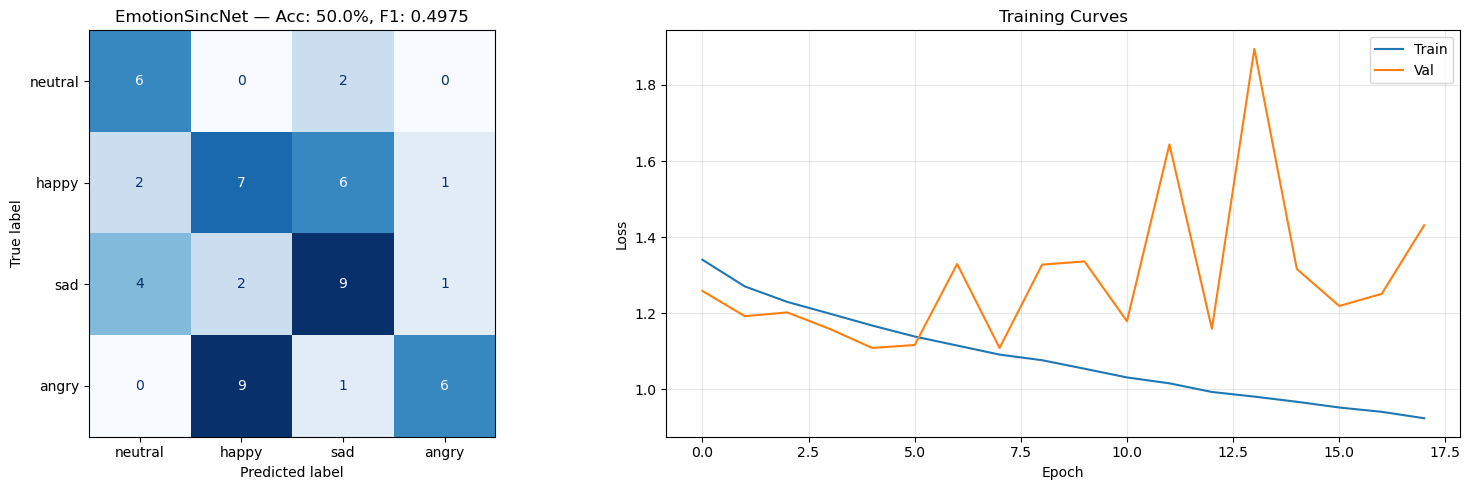

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cm = confusion_matrix(emo_labels, emo_preds)
ConfusionMatrixDisplay(cm, display_labels=EMOTION_LABELS).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'EmotionSincNet — Acc: {emo_acc:.1%}, F1: {emo_f1:.4f}')
axes[1].plot(emo_train_losses, label='Train'); axes[1].plot(emo_val_losses, label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].set_title('Training Curves')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('emotion_sincnet_curves.png', dpi=150); plt.show()

## 4. Model 2 — SpeakerSincNet

Uses a random split where all 24 speakers appear in train/val/test.
This is standard for closed-set speaker identification — the model
must have heard each speaker during training to recognise them.


In [6]:
spk_criterion = nn.CrossEntropyLoss()

set_seed(SEED)
spk_model = SpeakerSincNet(num_speakers=24, fc_hidden=512, dropout_rate=0.2).to(device)
spk_optimizer = torch.optim.RMSprop(spk_model.parameters(), lr=0.001, alpha=0.95, eps=1e-8)
print(f'SpeakerSincNet parameters: {sum(p.numel() for p in spk_model.parameters()):,}')

t0 = time.time()
best_vl, best_state, wait = float('inf'), None, 0
spk_train_losses, spk_val_losses = [], []

for epoch in range(MAX_EPOCHS):
    tl, ta = train_epoch(spk_model, spk_train_loader, spk_criterion, spk_optimizer, device, 'speaker', N_BATCHES)
    vl, va, _, _, _ = evaluate(spk_model, spk_val_loader, spk_criterion, device, 'speaker')
    spk_train_losses.append(tl)
    spk_val_losses.append(vl)

    if vl < best_vl:
        best_vl = vl
        best_state = {k: v.clone() for k, v in spk_model.state_dict().items()}
        wait = 0
    else:
        wait += 1

    if epoch % 5 == 0:
        print(f'  Epoch {epoch:3d} | Train: {tl:.4f} ({ta:.1%}) | Val: {vl:.4f} ({va:.1%})')
    if wait >= PATIENCE:
        print(f'  Early stopping at epoch {epoch+1}')
        break

spk_model.load_state_dict(best_state)
_, spk_acc, spk_f1, spk_preds, spk_labels = evaluate(spk_model, spk_test_loader, spk_criterion, device, 'speaker')
spk_time = time.time() - t0

best_spk = {'test_acc': spk_acc, 'test_f1': spk_f1, 'epochs': epoch+1,
            'preds': spk_preds, 'labels': spk_labels,
            'train_losses': spk_train_losses, 'val_losses': spk_val_losses}

torch.save(best_state, 'speaker_sincnet_best.pth')
print(f'\nSpeakerSincNet: Acc={spk_acc:.1%} F1={spk_f1:.4f} ({epoch+1} epochs, {spk_time:.0f}s)')

# Save confusion matrix as CSV
spk_cm = confusion_matrix(spk_labels, spk_preds)
spk_labels_list = [f'S{i+1}' for i in range(24)]
pd.DataFrame(spk_cm, index=spk_labels_list, columns=spk_labels_list).to_csv('speaker_confusion_matrix.csv')

# Save training curves as CSV
pd.DataFrame({'epoch': range(1, len(spk_train_losses)+1),
              'train_loss': spk_train_losses,
              'val_loss': spk_val_losses}).to_csv('speaker_training_curves.csv', index=False)

print('Saved: speaker_confusion_matrix.csv, speaker_training_curves.csv')

SpeakerSincNet parameters: 3,828,928
  Epoch   0 | Train: 2.9460 (10.7%) | Val: 2.3496 (45.8%)
  Epoch   5 | Train: 1.9145 (38.8%) | Val: 1.2419 (88.5%)
  Epoch  10 | Train: 1.5537 (50.1%) | Val: 0.8186 (90.6%)
  Epoch  15 | Train: 1.3559 (56.4%) | Val: 0.6594 (95.8%)
  Epoch  20 | Train: 1.2235 (60.5%) | Val: 0.5272 (91.7%)
  Epoch  25 | Train: 1.1167 (63.7%) | Val: 0.4545 (94.8%)
  Epoch  30 | Train: 1.0481 (65.7%) | Val: 0.4257 (94.8%)
  Epoch  35 | Train: 0.9823 (67.9%) | Val: 0.3971 (95.8%)
  Epoch  40 | Train: 0.9378 (69.4%) | Val: 0.3849 (92.7%)
  Epoch  45 | Train: 0.8974 (70.6%) | Val: 0.3257 (93.8%)
  Epoch  50 | Train: 0.8577 (72.0%) | Val: 0.3094 (93.8%)
  Epoch  55 | Train: 0.8176 (73.3%) | Val: 0.2991 (95.8%)
  Epoch  60 | Train: 0.7893 (74.1%) | Val: 0.2806 (93.8%)
  Epoch  65 | Train: 0.7686 (75.0%) | Val: 0.2820 (94.8%)
  Epoch  70 | Train: 0.7359 (76.0%) | Val: 0.2503 (94.8%)
  Epoch  75 | Train: 0.7122 (76.6%) | Val: 0.2440 (93.8%)
  Epoch  80 | Train: 0.6983 (77.2%)

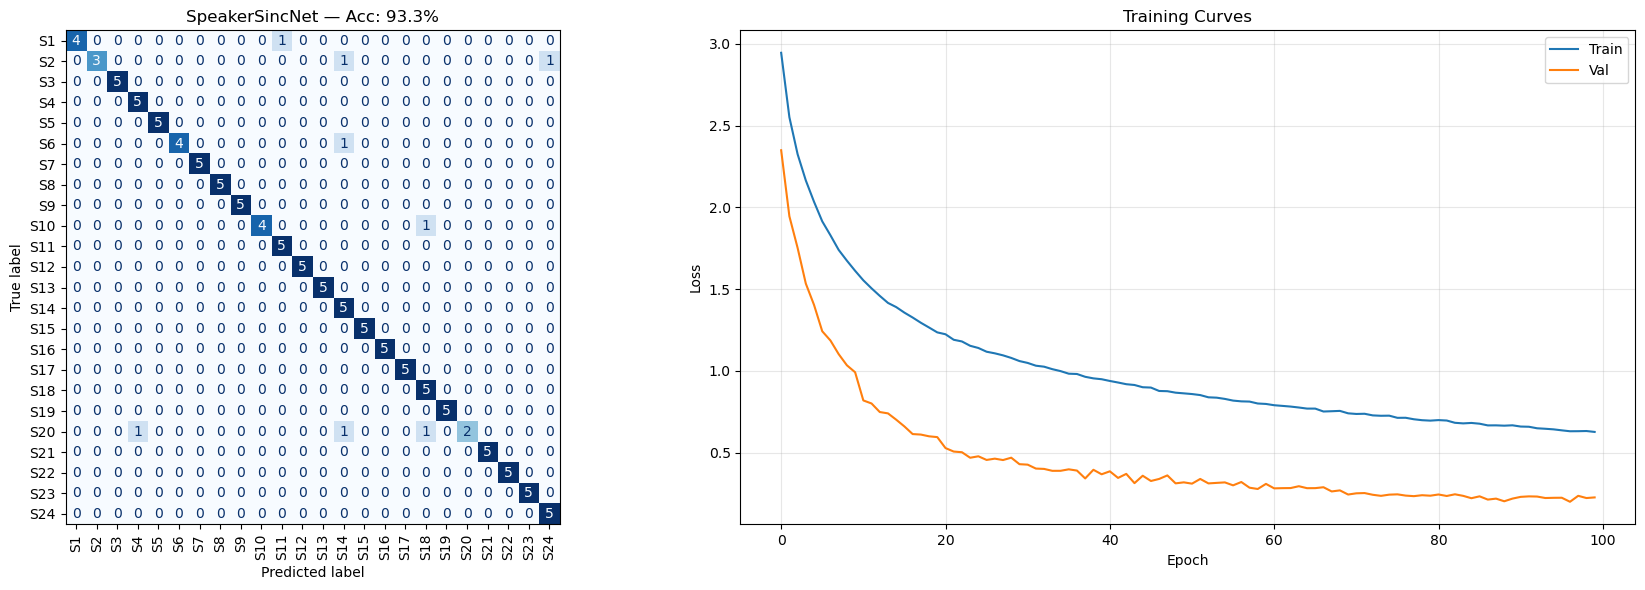

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
cm = confusion_matrix(spk_labels, spk_preds)
ConfusionMatrixDisplay(cm, display_labels=[f'S{i+1}' for i in range(24)]).plot(
    ax=axes[0], cmap='Blues', colorbar=False, xticks_rotation=90)
axes[0].set_title(f'SpeakerSincNet — Acc: {spk_acc:.1%}')
axes[1].plot(spk_train_losses, label='Train'); axes[1].plot(spk_val_losses, label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].set_title('Training Curves')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('speaker_sincnet_curves.png', dpi=150); plt.show()

## 5. Combined — MultiTaskSincNet

Uses the emotion (speaker-independent) split. The speaker head only sees
20 of 24 speakers during training — it acts as an auxiliary regulariser
to help the shared encoder learn better features for emotion recognition.


In [8]:
# Figure out which speakers are in the training split and remap their IDs
mt_train_speakers = sorted(set(s['speaker'] for s in emo_train))
mt_num_speakers = len(mt_train_speakers)
spk_remap = {orig: new for new, orig in enumerate(mt_train_speakers)}
print(f'Speakers in training split: {mt_num_speakers}/24')

lambda_values = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]
emo_w = compute_class_weights(emo_train).to(device)
mt_results = []

for lam in lambda_values:
    print(f'\n--- Lambda = {lam} ---')
    set_seed(SEED)

    model = MultiTaskSincNet(num_emotions=4, num_speakers=mt_num_speakers,
                              emo_fc=256, spk_fc=512, dropout_rate=0.2).to(device)
    emo_crit = nn.CrossEntropyLoss(weight=emo_w)
    spk_crit = nn.CrossEntropyLoss()
    optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001, alpha=0.95, eps=1e-8)

    best_vl, best_state, wait = float('inf'), None, 0
    train_losses, val_losses = [], []

    t0 = time.time()
    for epoch in range(MAX_EPOCHS):
        tl, ta = train_epoch_multitask(model, emo_train_loader, emo_crit, spk_crit,
                                        optimizer, device, lam, N_BATCHES, spk_remap)
        vl, va, _, _, _ = evaluate_multitask(model, emo_val_loader, emo_crit, device)
        train_losses.append(tl)
        val_losses.append(vl)

        if vl < best_vl:
            best_vl = vl
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if epoch % 10 == 0:
            print(f'  Epoch {epoch:3d} | Loss: {tl:.4f} | Val Emo Acc: {va:.1%}')
        if wait >= PATIENCE:
            break

    model.load_state_dict(best_state)
    _, emo_acc, emo_f1, emo_preds, emo_labels = evaluate_multitask(model, emo_test_loader, emo_crit, device)
    elapsed = time.time() - t0

    diff = emo_acc * 100 - best_emo['test_acc'] * 100
    print(f'  Result: {emo_acc:.1%} ({diff:+.1f}% vs single-task) | {epoch+1} epochs, {elapsed:.0f}s')

    mt_results.append({'lambda': lam, 'emo_acc': emo_acc, 'emo_f1': emo_f1,
                       'epochs': epoch+1, 'time': elapsed,
                       'emo_preds': emo_preds, 'emo_labels': emo_labels,
                       'train_losses': train_losses, 'val_losses': val_losses})

# Save lambda search results as CSV
lambda_df = pd.DataFrame([{
    'lambda': r['lambda'],
    'emotion_accuracy': round(r['emo_acc'] * 100, 2),
    'emotion_f1': round(r['emo_f1'], 4),
    'epochs': r['epochs'],
    'time_seconds': round(r['time'], 0)
} for r in mt_results])
lambda_df.to_csv('multitask_lambda_results.csv', index=False)
print('\nSaved: multitask_lambda_results.csv')
print(lambda_df.to_string(index=False))

Speakers in training split: 20/24

--- Lambda = 0.0 ---
  Epoch   0 | Loss: 1.3473 | Val Emo Acc: 37.5%
  Epoch  10 | Loss: 1.0413 | Val Emo Acc: 42.9%
  Result: 44.6% (-5.4% vs single-task) | 15 epochs, 328s

--- Lambda = 0.1 ---
  Epoch   0 | Loss: 1.6344 | Val Emo Acc: 35.7%
  Epoch  10 | Loss: 1.2272 | Val Emo Acc: 48.2%
  Result: 62.5% (+12.5% vs single-task) | 14 epochs, 318s

--- Lambda = 0.3 ---
  Epoch   0 | Loss: 2.1941 | Val Emo Acc: 37.5%
  Epoch  10 | Loss: 1.5336 | Val Emo Acc: 44.6%
  Result: 41.1% (-8.9% vs single-task) | 15 epochs, 331s

--- Lambda = 0.5 ---
  Epoch   0 | Loss: 2.7425 | Val Emo Acc: 41.1%
  Epoch  10 | Loss: 1.8387 | Val Emo Acc: 48.2%
  Epoch  20 | Loss: 1.5619 | Val Emo Acc: 50.0%
  Result: 60.7% (+10.7% vs single-task) | 29 epochs, 657s

--- Lambda = 0.7 ---
  Epoch   0 | Loss: 3.2972 | Val Emo Acc: 44.6%
  Epoch  10 | Loss: 2.1487 | Val Emo Acc: 48.2%
  Result: 60.7% (+10.7% vs single-task) | 18 epochs, 398s

--- Lambda = 1.0 ---
  Epoch   0 | Loss

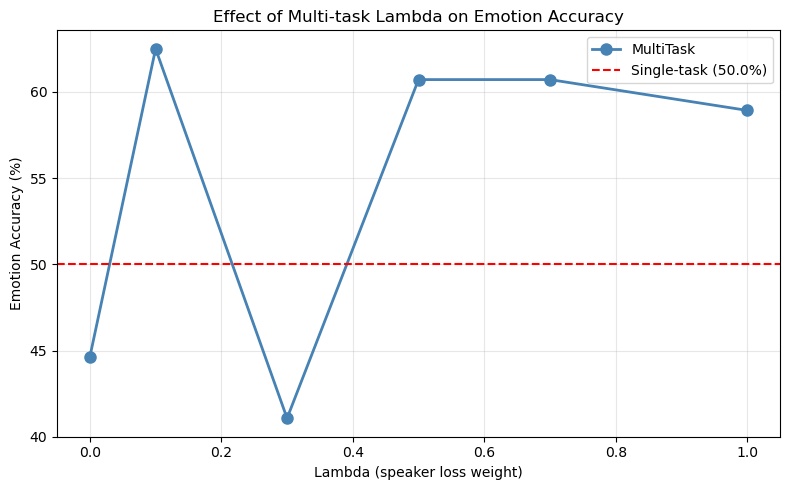

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
lams = [r['lambda'] for r in mt_results]
accs = [r['emo_acc'] * 100 for r in mt_results]
ax.plot(lams, accs, 'o-', linewidth=2, markersize=8, color='steelblue', label='MultiTask')
ax.axhline(y=best_emo['test_acc'] * 100, color='red', linestyle='--', label=f'Single-task ({best_emo["test_acc"]:.1%})')
ax.set_xlabel('Lambda (speaker loss weight)'); ax.set_ylabel('Emotion Accuracy (%)')
ax.set_title('Effect of Multi-task Lambda on Emotion Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('multitask_lambda_effect.png', dpi=150); plt.show()

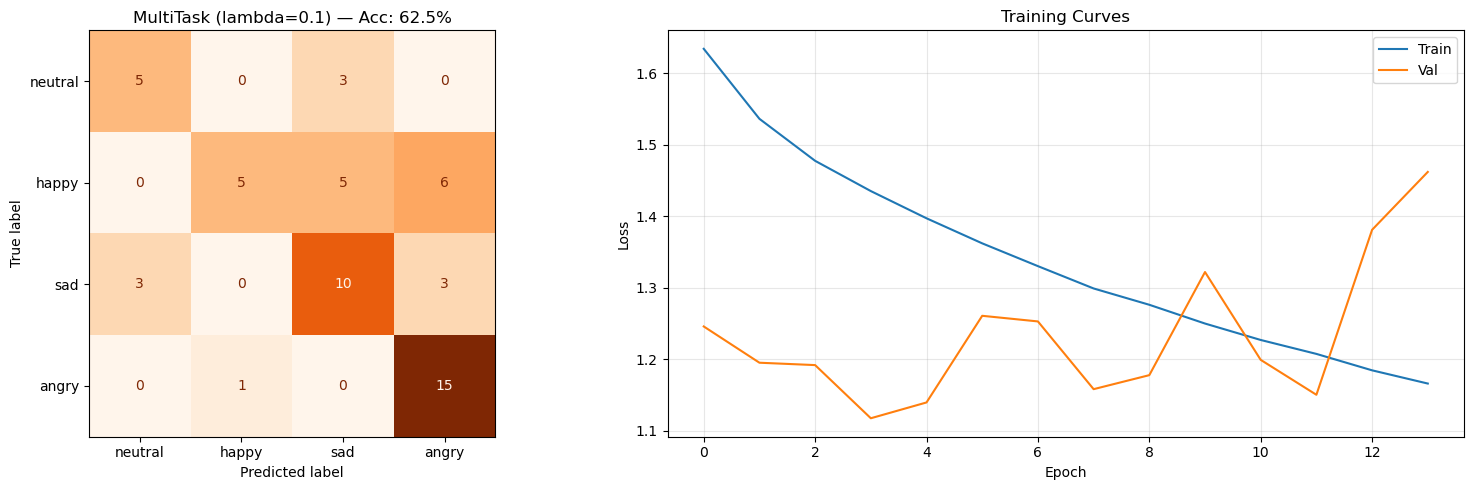

In [10]:
best_mt_idx = max(range(len(mt_results)), key=lambda i: mt_results[i]['emo_acc'])
bm = mt_results[best_mt_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cm = confusion_matrix(bm['emo_labels'], bm['emo_preds'])
ConfusionMatrixDisplay(cm, display_labels=EMOTION_LABELS).plot(ax=axes[0], cmap='Oranges', colorbar=False)
axes[0].set_title(f'MultiTask (lambda={bm["lambda"]}) — Acc: {bm["emo_acc"]:.1%}')
axes[1].plot(bm['train_losses'], label='Train'); axes[1].plot(bm['val_losses'], label='Val')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].set_title('Training Curves')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('multitask_sincnet_cm.png', dpi=150); plt.show()

## 6. Final Results


In [11]:
print('=' * 60)
print('FINAL RESULTS')
print('=' * 60)
print(f'\n{"Model":<30} {"Acc":>7} {"F1":>7}  Test Set')
print('-' * 60)
print(f'{"EmotionSincNet":<30} {best_emo["test_acc"]:6.1%} {best_emo["test_f1"]:.4f}  speaker-independent')
print(f'{"SpeakerSincNet":<30} {best_spk["test_acc"]:6.1%} {best_spk["test_f1"]:.4f}  random split (closed-set)')
print(f'{"MultiTask (lam=" + str(bm["lambda"]) + ")":<30} {bm["emo_acc"]:6.1%} {bm["emo_f1"]:.4f}  speaker-independent')
print('=' * 60)

# Save results to CSV
results_df = pd.DataFrame([
    {'model': 'EmotionSincNet', 'task': 'emotion', 'accuracy': round(best_emo['test_acc']*100, 2),
     'f1_score': round(best_emo['test_f1'], 4), 'test_split': 'speaker-independent', 'epochs': best_emo['epochs']},
    {'model': 'SpeakerSincNet', 'task': 'speaker', 'accuracy': round(best_spk['test_acc']*100, 2),
     'f1_score': round(best_spk['test_f1'], 4), 'test_split': 'random (closed-set)', 'epochs': best_spk['epochs']},
    {'model': f'MultiTask_lam{bm["lambda"]}', 'task': 'emotion', 'accuracy': round(bm['emo_acc']*100, 2),
     'f1_score': round(bm['emo_f1'], 4), 'test_split': 'speaker-independent', 'epochs': bm['epochs']},
])
results_df.to_csv('sincnet_final_results.csv', index=False)
print('\nSaved: sincnet_final_results.csv')
print(results_df.to_string(index=False))

FINAL RESULTS

Model                              Acc      F1  Test Set
------------------------------------------------------------
EmotionSincNet                  50.0% 0.4975  speaker-independent
SpeakerSincNet                  93.3% 0.9299  random split (closed-set)
MultiTask (lam=0.1)             62.5% 0.6015  speaker-independent

Saved: sincnet_final_results.csv
           model    task  accuracy  f1_score          test_split  epochs
  EmotionSincNet emotion     50.00    0.4975 speaker-independent      18
  SpeakerSincNet speaker     93.33    0.9299 random (closed-set)     100
MultiTask_lam0.1 emotion     62.50    0.6015 speaker-independent      14
